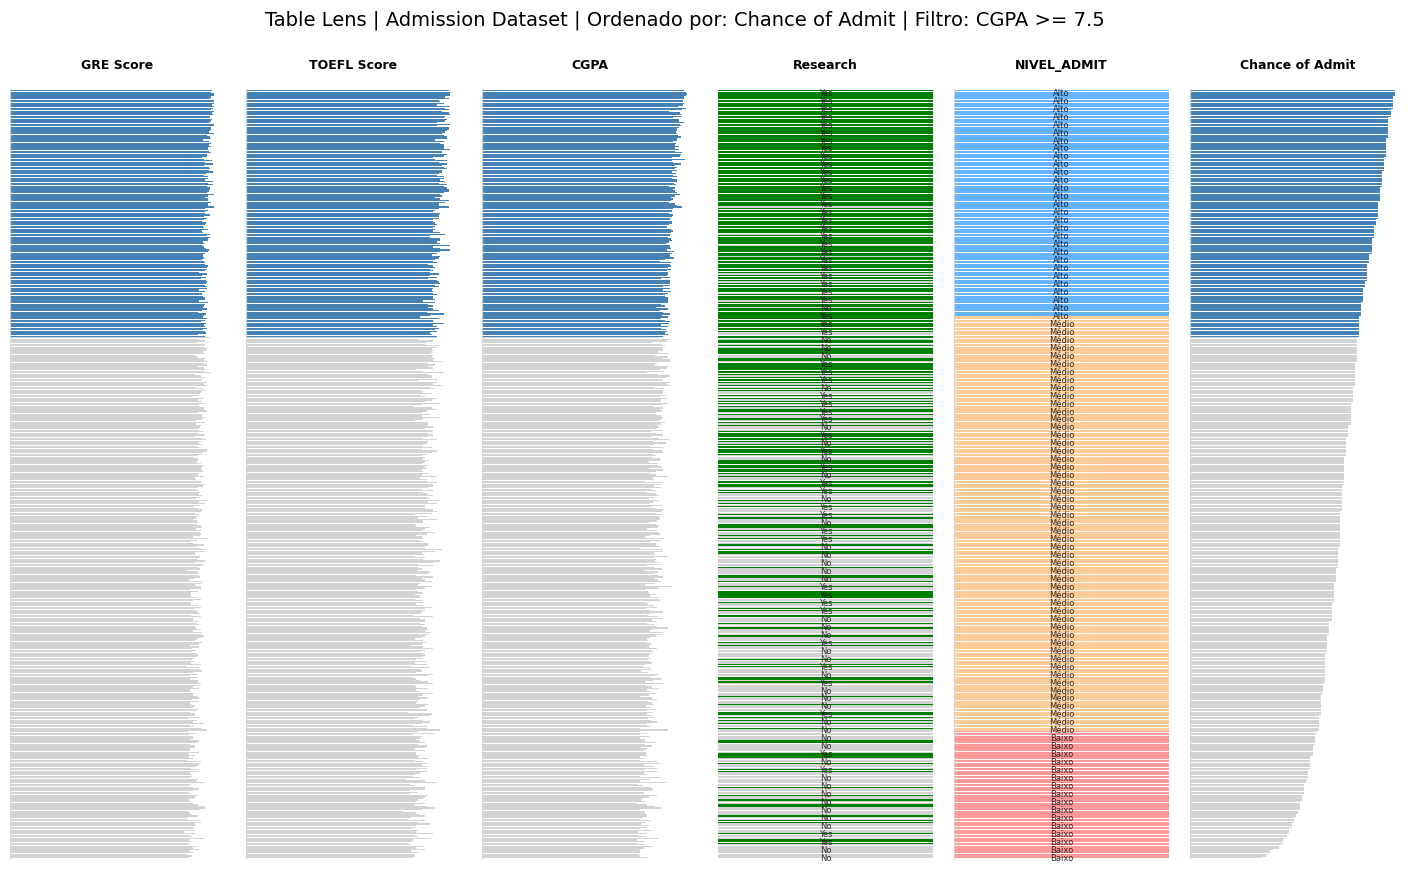

In [14]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



caminho_arquivo = '/content/Admission_Predict_Ver1.1.csv'

df = pd.read_csv(caminho_arquivo)


df = df.drop(columns=['Serial No.'])

df.columns = [col.strip() for col in df.columns]

df['NIVEL_ADMIT'] = pd.cut(
    df['Chance of Admit'],
    bins=[0, 0.6, 0.8, 1],
    labels=['Baixo', 'Médio', 'Alto']
)



df_filtrado = df[df['CGPA'] >= 7.5].copy()


coluna_ordenacao = 'Chance of Admit'

df_sorted = df_filtrado.sort_values(by=coluna_ordenacao, ascending=True).reset_index(drop=True)


colunas_vis = [
    'GRE Score',
    'TOEFL Score',
    'CGPA',
    'Research',
    'NIVEL_ADMIT',
    'Chance of Admit'
]

tipos_vis = [
    'quantitativa',
    'quantitativa',
    'quantitativa',
    'nominal',
    'ordinal',
    'quantitativa'
]



fig, axes = plt.subplots(nrows=1, ncols=len(colunas_vis), figsize=(18, 10), sharey=True)
plt.subplots_adjust(wspace=0.1)

y_pos = np.arange(len(df_sorted))

cores_ordinais = {
    'Baixo': '#ff9999',
    'Médio': '#ffcc99',
    'Alto': '#66b3ff'
}

limite_foco = 0.8



for i, (col, tipo) in enumerate(zip(colunas_vis, tipos_vis)):
    ax = axes[i]

    if tipo == 'quantitativa':
        cores = [
            'steelblue' if v >= limite_foco else 'lightgray'
            for v in df_sorted['Chance of Admit']
        ]
        ax.barh(y_pos, df_sorted[col], color=cores, height=0.8)
        ax.set_xticks([])

    elif tipo == 'ordinal':
        cores = df_sorted[col].map(cores_ordinais).tolist()
        ax.barh(y_pos, [1]*len(df_sorted), color=cores, height=0.8)
        ax.set_xticks([])
        ax.set_xlim(0, 1)


        for j, val in enumerate(df_sorted[col]):
            if j % 5 == 0:
                ax.text(0.5, j, str(val), ha='center', va='center', fontsize=6, alpha=0.8)

    elif tipo == 'nominal':
        cores = df_sorted[col].map({0: 'lightgray', 1: 'green'}).tolist()
        ax.barh(y_pos, [1]*len(df_sorted), color=cores, height=0.8)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlim(0, 1)

        for j, val in enumerate(df_sorted[col]):
            if j % 5 == 0:
                texto = 'Yes' if val == 1 else 'No'
                ax.text(0.5, j, texto, ha='center', va='center', fontsize=6, alpha=0.8)

    ax.set_title(col, fontsize=9, fontweight='bold', pad=15)
    ax.set_ylim(-1, len(df_sorted))

    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    if tipo != 'nominal':
        ax.spines['left'].set_color('lightgray')
    else:
        ax.spines['left'].set_visible(False)

# ==============================
# TÍTULO
# ==============================

plt.suptitle(
    f'Table Lens | Admission Dataset | Ordenado por: {coluna_ordenacao} | Filtro: CGPA >= 7.5',
    fontsize=14,
    y=0.96
)

plt.savefig('table_lens_admission.png', dpi=300, bbox_inches='tight')

plt.show()